# Phase 3 - Similar-Question Recommender: Model, Pipeline & Predictions

**Project:** Stack Overflow C++ semantic *similar-question recommendation* (continued from Phases 1-2).

**What this phase adds.** Phase 2 built an exploratory hybrid recommender. Phase 3 turns it into a
production-shaped system:

1. **Model development & selection (Section 1)** - several candidate retrieval models are compared under a
   time-ordered train/validation/test split, and the best is chosen by *cross-validated* ranking quality.
2. **Training & evaluation (Section 2)** - the chosen model is tuned on validation, then measured **once** on
   the held-out test set with standard ranking metrics and against random / popularity baselines.
3. **End-to-end pipeline (Section 3)** - a **training pipeline** fits and saves the model, and a separate
   **prediction pipeline** loads it, retrieves the top-K similar questions for unseen questions, and **saves the
   recommendations back into the database**.
4. **MLflow tracking (Section 4, bonus)** - every run's parameters, metrics, and artefacts are logged.

> This notebook **loads the pipeline's saved outputs** (it does not retrain), so the report always matches what
> `run_pipeline.py` produced. Run `python run_pipeline.py` first to regenerate everything.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
REPORTS = PROJECT_ROOT / "data" / "reports"

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})
ACCENT, MUTED = "#2563eb", "#94a3b8"

report = json.loads((REPORTS / "phase3_training_report.json").read_text())
print("Task           :", report["task"])
print("Split (temporal):", report["split"])
print("Candidate models:", ", ".join(report["candidate_models"]))
print("Selected model  :", report["selected_best_model"])

Task           : semantic_similar_question_recommendation
Split (temporal): {'type': 'temporal', 'train_rows': 1750, 'validation_rows': 375, 'test_rows': 375}
Candidate models: title_word_tfidf, document_word_tfidf, char_wb_tfidf, lsa_document, bm25_document, hybrid
Selected model  : hybrid


## Section 1 - Model development and model selection

Six candidates compete: four TF-IDF/LSA cosine models, the new **BM25** probabilistic ranker, and a **hybrid**
blend of all five. Selection uses **5-fold cross-validation over the validation queries** (only the query set is
folded; the candidate pool is fixed), scored by **nDCG@10**. Reporting mean +/- std makes the choice robust to
which questions happen to fall in validation.

In [2]:
selection = pd.read_csv(REPORTS / "section1_model_selection.csv")
selection_view = selection[["model", "type", "cv_nDCG@10_mean", "cv_nDCG@10_std",
                            "val_Hit@10", "val_MRR@10", "val_nDCG@10"]].round(4)
selection_view

,model,type,cv_nDCG@10_mean,cv_nDCG@10_std,val_Hit@10,val_MRR@10,val_nDCG@10
0,hybrid,ensemble,0.3665,0.0264,0.8230,0.5723,0.3666
1,char_wb_tfidf,single,0.3641,0.0275,0.8201,0.5557,0.3642
2,document_word_tfidf,single,0.3352,0.0278,0.8142,0.5306,0.3352
3,bm25_document,single,0.2904,0.0289,0.7817,0.4954,0.2906
4,lsa_document,single,0.2860,0.0303,0.7168,0.4393,0.2861
5,title_word_tfidf,single,0.1687,0.0193,0.5988,0.3081,0.1688


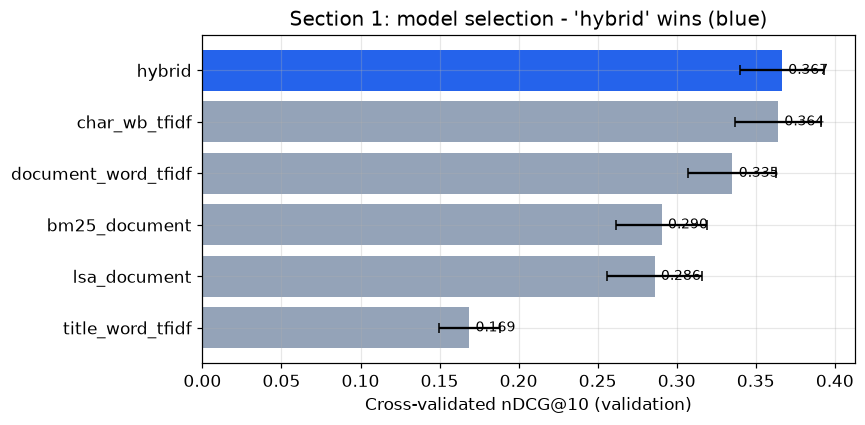

In [3]:
# Cross-validated nDCG@10 per candidate (error bars = std across folds).
sel = selection.sort_values("cv_nDCG@10_mean")
best = report["selected_best_model"]
colors = [ACCENT if m == best else MUTED for m in sel["model"]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(sel["model"], sel["cv_nDCG@10_mean"], xerr=sel["cv_nDCG@10_std"],
        color=colors, capsize=3)
ax.set_xlabel("Cross-validated nDCG@10 (validation)")
ax.set_title(f"Section 1: model selection - '{best}' wins (blue)")
for y, v in enumerate(sel["cv_nDCG@10_mean"]):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

The **hybrid** blend is the strongest candidate, narrowly ahead of the character n-gram model (which is very
strong on its own because C++ questions share syntax, library, and error-string fragments). BM25 and LSA add
complementary signal, so the tuned blend edges out every single model. The tiny standard deviations show the
ranking of candidates is stable across folds - the choice is not a fluke of one validation split.

## Section 2 - Training and evaluation on the held-out test set

The selected model is evaluated **exactly once** on the temporally-latest 15% of questions (never seen during
fitting or selection). We report Hit@K, Recall@K, MAP@K, MRR@K, and nDCG@K, and compare against two sanity
baselines: **random** ordering and a **popularity** ranking (always recommend the most-viewed questions).

In [4]:
test_metrics = pd.read_csv(REPORTS / "section2_test_metrics.csv").iloc[0]
rows = []
for k in (5, 10, 20):
    rows.append({"K": k, "Hit@K": test_metrics[f"Hit@{k}"], "Recall@K": test_metrics[f"Recall@{k}"],
                 "MAP@K": test_metrics[f"MAP@{k}"], "MRR@K": test_metrics[f"MRR@{k}"],
                 "nDCG@K": test_metrics[f"nDCG@{k}"]})
print(f"Evaluated queries: {int(test_metrics['evaluated_queries'])}  "
      f"(coverage {test_metrics['coverage']:.1%} of test questions had a relevant neighbour)")
pd.DataFrame(rows).set_index("K").round(4)

Evaluated queries: 323  (coverage 86.1% of test questions had a relevant neighbour)


,Hit@K,Recall@K,MAP@K,MRR@K,nDCG@K
K,,,,,
5,0.7245,0.0839,0.3077,0.5621,0.3957
10,0.8266,0.1231,0.2451,0.5760,0.3592
20,0.8885,0.1752,0.1898,0.5804,0.3232


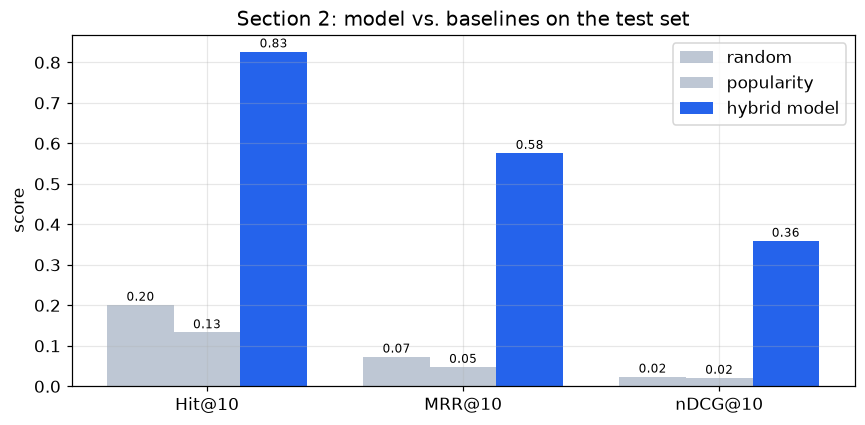

In [5]:
baselines = pd.read_csv(REPORTS / "section2_baseline_vs_model_test.csv", index_col=0)
labels = ["random", "popularity", f"selected_model[{report['selected_best_model']}]"]
present = [l for l in labels if l in baselines.index]
metrics_to_plot = ["Hit@10", "MRR@10", "nDCG@10"]
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(metrics_to_plot))
width = 0.26
for i, name in enumerate(present):
    vals = [baselines.loc[name, m] for m in metrics_to_plot]
    color = ACCENT if "selected_model" in name else MUTED
    disp = "hybrid model" if "selected_model" in name else name
    bars = ax.bar([xi + i * width for xi in x], vals, width, label=disp,
                  color=color, alpha=1.0 if "selected_model" in name else 0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)
ax.set_xticks([xi + width for xi in x]); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel("score"); ax.set_title("Section 2: model vs. baselines on the test set")
ax.legend(); plt.tight_layout(); plt.show()

The recommender beats both baselines by a wide margin - roughly **4x** the random Hit@10 and far above
popularity - confirming it captures genuine topical similarity rather than just surfacing popular questions.

## Section 3 - The end-to-end pipeline and predictions in the database

The **training pipeline** (`import_to_db -> load_data -> preprocess -> train_model`) saved a deployment artefact.
The **prediction pipeline** (`load_data -> preprocess -> make_predictions`) loaded it, scored the reserved
holdout questions, and wrote their recommendations into a `recommendations` table. Below we reproduce a live
recommendation and then read the stored predictions straight back from SQLite.

In [6]:
import recommender as R  # noqa: E402  (needs scripts/ on the path, set above)

artifact = joblib.load(PROJECT_ROOT / "data" / "models" / "best_recommender.joblib")
processed = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "preprocessed_questions.csv")
holdout = json.loads((PROJECT_ROOT / "data" / "models" / "holdout_test_ids.json").read_text())
holdout_ids = set(holdout["holdout_test_question_ids"])

sample = processed[processed["question_id"].isin(holdout_ids)].iloc[[7]]
print("QUERY QUESTION:")
print(" ", sample.iloc[0]["title"])
print("\nTOP-5 RECOMMENDED SIMILAR QUESTIONS (model:", artifact.best_model_name + "):")
for rec in R.recommend(artifact, sample, top_k=5)[0]:
    print(f"  {rec['rank']}. [{rec['score']:.3f}] {rec['recommended_title']}")

QUERY QUESTION:
  Why does initializing std::atomic_flag with false work on GCC and Clang but not Visual Studio?

TOP-5 RECOMMENDED SIMILAR QUESTIONS (model: hybrid):
  1. [0.748] Clang accepts designated initialization where GCC/MSVC reject — compiler bug or invalid C++?
  2. [0.699] Nested class friend function access works in gcc and clang but not in msvc
  3. [0.560] What is ATOMIC_FLAG_INIT and how is it supposed to be used?
  4. [0.559] MSVC accepts lambda with deleted parameterized ctor while GCC and Clang rejects
  5. [0.544] Why does a class inherited from lambda type lack conversion to function pointer in Visual C++?


In [7]:
# Read the stored predictions back from the database (proof they were persisted).
from database_connection import get_engine  # noqa: E402
from sqlalchemy import text  # noqa: E402

engine = get_engine()
with engine.connect() as conn:
    total = conn.execute(text("SELECT COUNT(*) FROM recommendations")).scalar_one()
    n_queries = conn.execute(text("SELECT COUNT(DISTINCT query_question_id) FROM recommendations")).scalar_one()
    stored = pd.read_sql_query(text("""
        SELECT r.query_question_id, r.rank, r.recommended_question_id, ROUND(r.score, 4) AS score,
               q.title AS recommended_title
        FROM recommendations r
        JOIN questions q ON q.question_id = r.recommended_question_id
        WHERE r.query_question_id = (SELECT query_question_id FROM recommendations ORDER BY query_question_id LIMIT 1)
        ORDER BY r.rank
    """), conn)
engine.dispose()
print(f"recommendations table: {total} rows for {n_queries} distinct query questions (top-10 each).")
stored

recommendations table: 3750 rows for 375 distinct query questions (top-10 each).


,query_question_id,rank,recommended_question_id,score,recommended_title
0,79907170,1,32897858,0.6726,What is the difference between boost::containe...
1,79907170,2,33273550,0.6549,"Why does `int ;` compile fine in C, but not in..."
2,79907170,3,79890215,0.6165,Three-way comparison (&lt;=&gt;) with anonymou...
3,79907170,4,79831249,0.6000,What is the optimal way to define a global con...
4,79907170,5,79843818,0.5973,Avoiding templates when working with different...
5,79907170,6,61240589,0.5970,How to initialize a struct to 0 in C++
6,79907170,7,44734397,0.5884,Which C++ standard is the default when compili...
7,79907170,8,79844065,0.5852,Is GCC right when it accepts a class template ...
8,79907170,9,69324725,0.5710,When are C++ default constructors implicitly d...
9,79907170,10,6919405,0.5684,Mystical restriction on std::binary_search


## Section 4 - MLflow experiment tracking (bonus)

Each training run logs its parameters (chosen model, hybrid weights, split sizes), metrics (test and CV scores),
and artefacts (the model + the training report JSON) to a local MLflow store under `mlruns/`. Launch the UI with
`mlflow ui --backend-store-uri mlruns` to browse and compare runs.

In [8]:
try:
    import mlflow
    mlflow.set_tracking_uri((PROJECT_ROOT / "mlruns").as_uri())
    exp = mlflow.get_experiment_by_name("phase3_similar_question_recommender")
    runs = mlflow.search_runs([exp.experiment_id])
    metric_cols = [c for c in runs.columns if c.startswith("metrics.")]
    show = runs[["run_id"] + metric_cols].copy()
    show.columns = [c.replace("metrics.", "") for c in show.columns]
    show["run_id"] = show["run_id"].str.slice(0, 8)
    display(show.round(4))
except Exception as exc:
    print("MLflow store not available:", exc)

,run_id,cv_best_nDCG_at_10,test_MRR_at_10,test_Recall_at_10,test_MAP_at_10,test_nDCG_at_10,test_Hit_at_10
0,9e8bc63c,0.3665,0.576,0.1231,0.2451,0.3592,0.8266
1,5b77065d,0.3665,0.576,0.1231,0.2451,0.3592,0.8266


## Conclusion - business view, limitations, and future work

**What it does.** Given any C++ question, the system instantly returns the most similar previously-asked
questions. On unseen (temporally-later) questions it lands a relevant neighbour in the top-10 about **83%** of
the time - useful for de-duplicating questions, suggesting "related questions", and routing askers to existing
answers before they wait for a new one.

**Why it is trustworthy.** A time-ordered split (never recommending the future to the past), fitting on training
data only, cross-validated model selection, and a single held-out test evaluation together guard against
over-optimistic numbers. The model beats random and popularity baselines by a wide margin.

**Limitations.** Relevance is measured with a *weak* label (shared secondary tag), which understates credit for
semantically-related questions that use different words; the corpus is 2.5k C++ questions; and the models are
lexical/latent (no large neural embedding), chosen deliberately for reproducibility and to run anywhere.

**Future work.** Add a sentence-embedding model as an extra hybrid component, expand the corpus via the resumable
crawler, collect real click/duplicate feedback for stronger relevance labels, and serve recommendations behind a
small API that reads the `recommendations` table.